# Dataset Understanding — IEEE-CIS Fraud Detection

**Goal:** Characterise the raw data statistically and derive concrete preprocessing decisions.

| Table | Rows | Columns |
|---|---|---|
| `train_transaction` | 590,540 | 394 |
| `train_identity` | 144,233 | 41 |

The two tables join on `TransactionID`.
Identity data is available for only ~24% of transactions.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

DATA = "../data/raw/"
print("Libraries loaded.")

Libraries loaded.


## 2. Load Data

In [2]:
trn = pd.read_csv(DATA + "train_transaction.csv")
idn = pd.read_csv(DATA + "train_identity.csv")

print(f"Transaction table : {trn.shape[0]:,} rows x {trn.shape[1]} cols")
print(f"Identity table    : {idn.shape[0]:,} rows x {idn.shape[1]} cols")

df = trn.merge(idn, on="TransactionID", how="left")
print(f"Merged table      : {df.shape[0]:,} rows x {df.shape[1]} cols")

Transaction table : 590,540 rows x 394 cols
Identity table    : 144,233 rows x 41 cols
Merged table      : 590,540 rows x 434 cols


## 3. Target Variable — Class Imbalance

isFraud value counts:
          count     pct
isFraud                
0        569877 96.5010
1         20663  3.4990


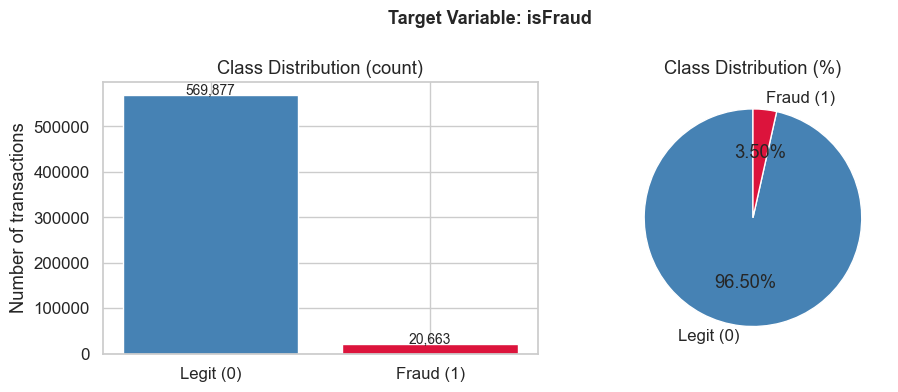

Imbalance ratio (legit:fraud) = 27.6:1


In [3]:
fraud_counts = trn["isFraud"].value_counts()
fraud_pct    = trn["isFraud"].value_counts(normalize=True) * 100

print("isFraud value counts:")
print(pd.DataFrame({"count": fraud_counts, "pct": fraud_pct}).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Legit (0)", "Fraud (1)"], fraud_counts.values,
            color=["steelblue", "crimson"])
axes[0].set_title("Class Distribution (count)")
axes[0].set_ylabel("Number of transactions")
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)

axes[1].pie(fraud_counts.values, labels=["Legit (0)", "Fraud (1)"],
            autopct="%1.2f%%", colors=["steelblue", "crimson"], startangle=90)
axes[1].set_title("Class Distribution (%)")

plt.suptitle("Target Variable: isFraud", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

ratio = fraud_counts[0] / fraud_counts[1]
print(f"Imbalance ratio (legit:fraud) = {ratio:.1f}:1")

## 4. Missing Value Analysis

--- train_transaction ---
Columns with missing values : 374 / 394
Rows with at least one NaN  : 590,540
--- train_identity ---
Columns with missing values : 38 / 41
Rows with at least one NaN  : 143,298


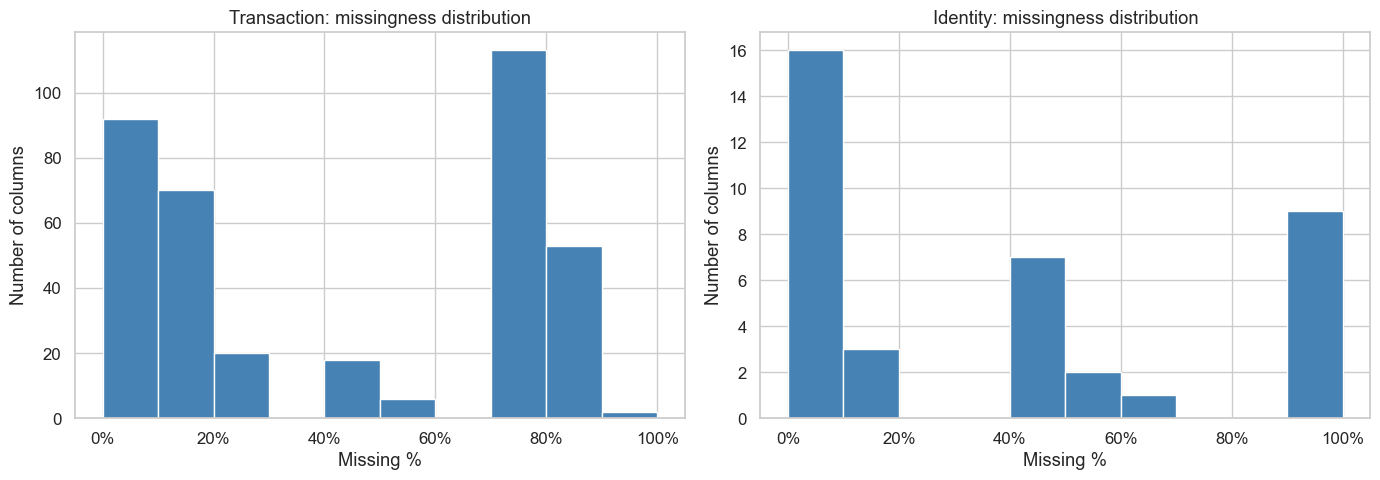

Transaction table — columns by missingness bucket:
      <10%: 92 columns
    10-30%: 90 columns
    30-60%: 24 columns
      >60%: 168 columns


In [4]:
def missing_report(frame, label):
    miss = frame.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    pct  = miss / len(frame) * 100
    report = pd.DataFrame({"missing_count": miss, "missing_pct": pct})
    print(f"--- {label} ---")
    print(f"Columns with missing values : {len(report)} / {frame.shape[1]}")
    print(f"Rows with at least one NaN  : {frame.isnull().any(axis=1).sum():,}")
    return report

trn_miss = missing_report(trn, "train_transaction")
idn_miss = missing_report(idn, "train_identity")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, miss, title in zip(
    axes,
    [trn_miss["missing_pct"], idn_miss["missing_pct"]],
    ["Transaction: missingness distribution", "Identity: missingness distribution"],
):
    ax.hist(miss.values, bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
            color="steelblue", edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Missing %")
    ax.set_ylabel("Number of columns")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

buckets = {"<10%": 0, "10-30%": 0, "30-60%": 0, ">60%": 0}
for p in trn_miss["missing_pct"]:
    if p < 10:   buckets["<10%"]   += 1
    elif p < 30: buckets["10-30%"] += 1
    elif p < 60: buckets["30-60%"] += 1
    else:        buckets[">60%"]   += 1

print("Transaction table — columns by missingness bucket:")
for k, v in buckets.items():
    print(f"  {k:>8}: {v} columns")

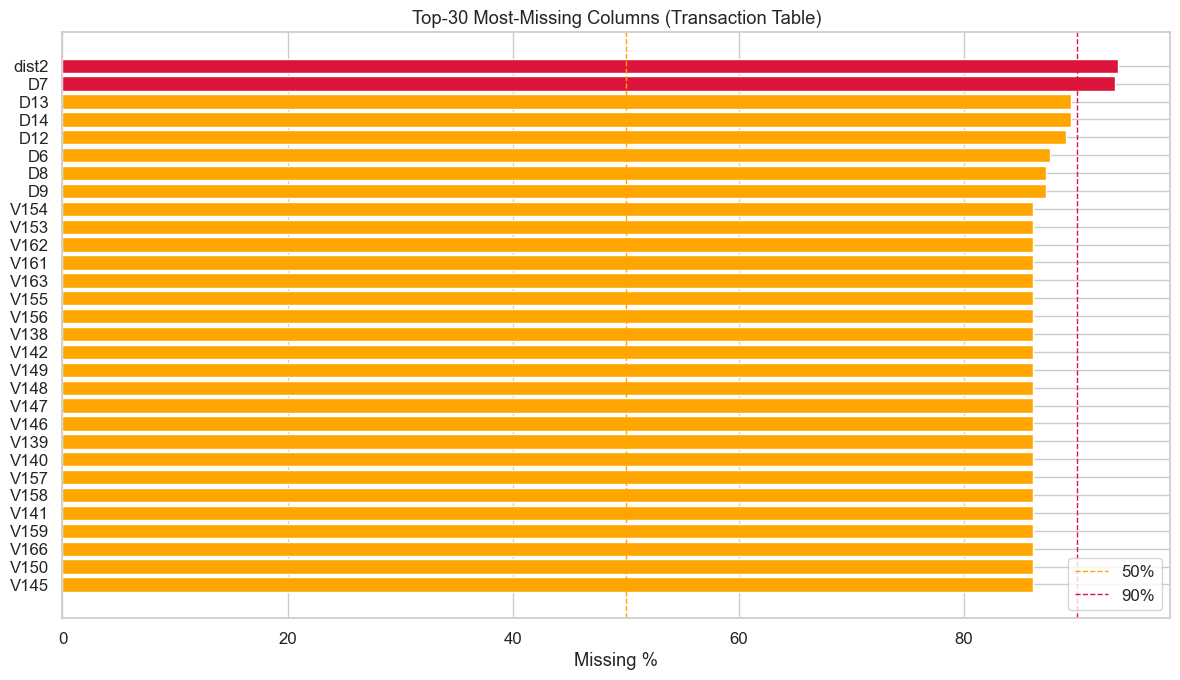

In [5]:
top30 = trn_miss.head(30)
fig, ax = plt.subplots(figsize=(12, 7))
colors = [
    "crimson" if p > 90 else ("orange" if p > 50 else "steelblue")
    for p in top30["missing_pct"]
]
ax.barh(top30.index[::-1], top30["missing_pct"][::-1], color=colors[::-1])
ax.axvline(50, color="orange", ls="--", lw=1, label="50%")
ax.axvline(90, color="crimson", ls="--", lw=1, label="90%")
ax.set_xlabel("Missing %")
ax.set_title("Top-30 Most-Missing Columns (Transaction Table)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Data Types & Feature Groups

In [6]:
def classify_features(frame):
    cats = [c for c in frame.columns if frame[c].dtype == "object"]
    nums = [c for c in frame.columns
            if frame[c].dtype != "object" and c != "TransactionID"]
    return cats, nums

trn_cats, trn_nums = classify_features(trn)
idn_cats, idn_nums = classify_features(idn)

print("TRANSACTION TABLE")
print(f"  Numerical  : {len(trn_nums)}")
print(f"  Categorical: {len(trn_cats)} -> {trn_cats}")
print("IDENTITY TABLE")
print(f"  Numerical  : {len(idn_nums)}")
print(f"  Categorical: {len(idn_cats)} -> {idn_cats}")

groups = {
    "C (count)":      [c for c in trn.columns if c.startswith("C")],
    "D (timedelta)":  [c for c in trn.columns if c.startswith("D")],
    "M (match)":      [c for c in trn.columns if c.startswith("M")],
    "V (Vesta eng.)": [c for c in trn.columns if c.startswith("V")],
    "card":           [c for c in trn.columns if c.startswith("card")],
    "addr":           [c for c in trn.columns if c.startswith("addr")],
    "id_":            [c for c in idn.columns  if c.startswith("id_")],
}
print("Feature groups:")
for g, cols in groups.items():
    print(f"  {g:<18}: {len(cols):>3} features")

TRANSACTION TABLE
  Numerical  : 379
  Categorical: 14 -> ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
IDENTITY TABLE
  Numerical  : 23
  Categorical: 17 -> ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
Feature groups:
  C (count)         :  14 features
  D (timedelta)     :  15 features
  M (match)         :   9 features
  V (Vesta eng.)    : 339 features
  card              :   6 features
  addr              :   2 features
  id_               :  38 features


## 6. Numerical Features — Skewness & Kurtosis

Columns with |skewness| > 5 : 278 / 379
Columns with |skewness| > 10: 211


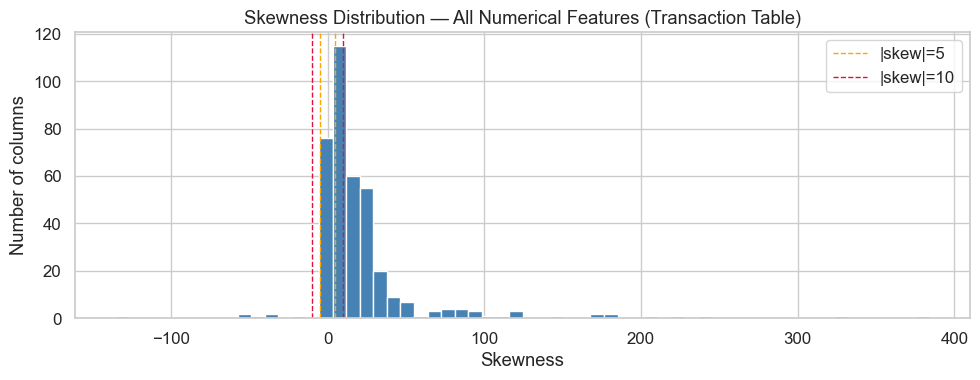

Top-10 most skewed features:
V305   384.2262
V311   323.8314
V129   240.2743
V309   224.8753
V206   207.8816
V319   181.8337
V269   177.8390
V266   175.9588
V334   168.4728
V135   144.8832


In [7]:
num_stats = trn[trn_nums].describe(percentiles=[.01, .25, .5, .75, .99]).T
num_stats["skewness"]    = trn[trn_nums].skew()
num_stats["kurtosis"]    = trn[trn_nums].kurt()
num_stats["missing_pct"] = (trn[trn_nums].isnull().mean() * 100).round(2)

high_skew = num_stats[num_stats["skewness"].abs() > 5]
print(f"Columns with |skewness| > 5 : {len(high_skew)} / {len(trn_nums)}")
print(f"Columns with |skewness| > 10: {(num_stats['skewness'].abs() > 10).sum()}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(num_stats["skewness"].dropna(), bins=60, color="steelblue", edgecolor="white")
ax.axvline(-5,  color="orange", ls="--", lw=1)
ax.axvline( 5,  color="orange", ls="--", lw=1, label="|skew|=5")
ax.axvline(-10, color="crimson", ls="--", lw=1)
ax.axvline( 10, color="crimson", ls="--", lw=1, label="|skew|=10")
ax.set_xlabel("Skewness")
ax.set_ylabel("Number of columns")
ax.set_title("Skewness Distribution — All Numerical Features (Transaction Table)")
ax.legend()
plt.tight_layout()
plt.show()

print("Top-10 most skewed features:")
print(num_stats["skewness"].abs().sort_values(ascending=False).head(10).to_string())

## 7. Transaction Amount Analysis

TransactionAmt descriptive stats:
count   590540.0000
mean       135.0272
std        239.1625
min          0.2510
1%           9.2440
5%          20.0000
25%         43.3210
50%         68.7690
75%        125.0000
95%        445.0000
99%       1104.0000
max      31937.3910
Skewness : 14.374
Kurtosis : 1123.957


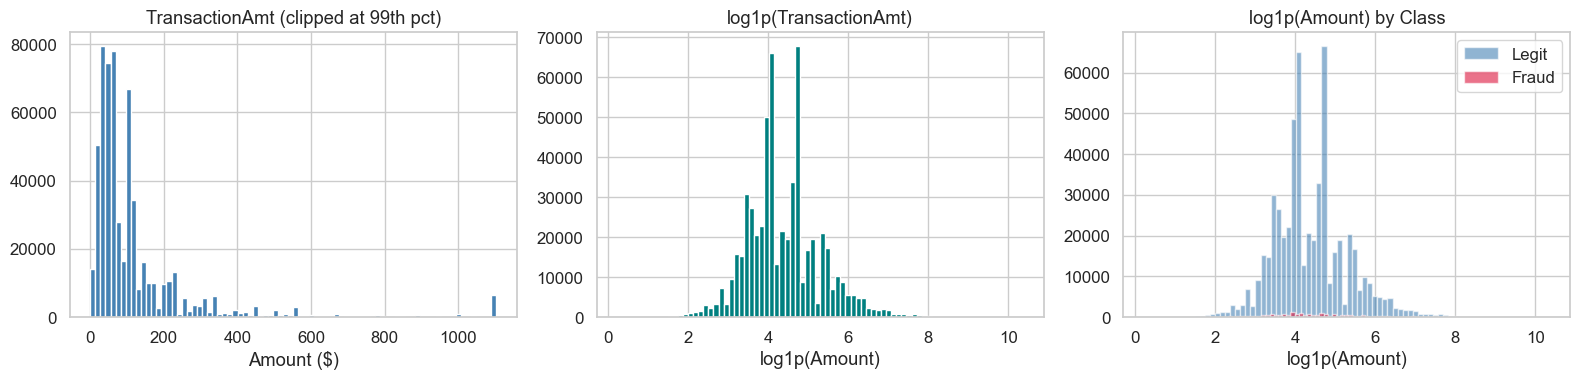

In [8]:
amt = trn["TransactionAmt"]
print("TransactionAmt descriptive stats:")
print(amt.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_string())
print(f"Skewness : {amt.skew():.3f}")
print(f"Kurtosis : {amt.kurt():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(amt.clip(upper=amt.quantile(0.99)), bins=80,
             color="steelblue", edgecolor="white")
axes[0].set_title("TransactionAmt (clipped at 99th pct)")
axes[0].set_xlabel("Amount ($)")

axes[1].hist(np.log1p(amt), bins=80, color="teal", edgecolor="white")
axes[1].set_title("log1p(TransactionAmt)")
axes[1].set_xlabel("log1p(Amount)")

axes[2].hist(np.log1p(trn.loc[trn["isFraud"] == 0, "TransactionAmt"]),
             bins=80, alpha=0.6, color="steelblue", label="Legit")
axes[2].hist(np.log1p(trn.loc[trn["isFraud"] == 1, "TransactionAmt"]),
             bins=80, alpha=0.6, color="crimson", label="Fraud")
axes[2].set_title("log1p(Amount) by Class")
axes[2].set_xlabel("log1p(Amount)")
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. Time Feature (TransactionDT)

TransactionDT stats (seconds offset from reference):
count     590540.0000
mean     7372311.3101
std      4617223.6465
min        86400.0000
25%      3027057.7500
50%      7306527.5000
75%     11246620.0000
max     15811131.0000
Span: 182.0 days  (6.1 months)


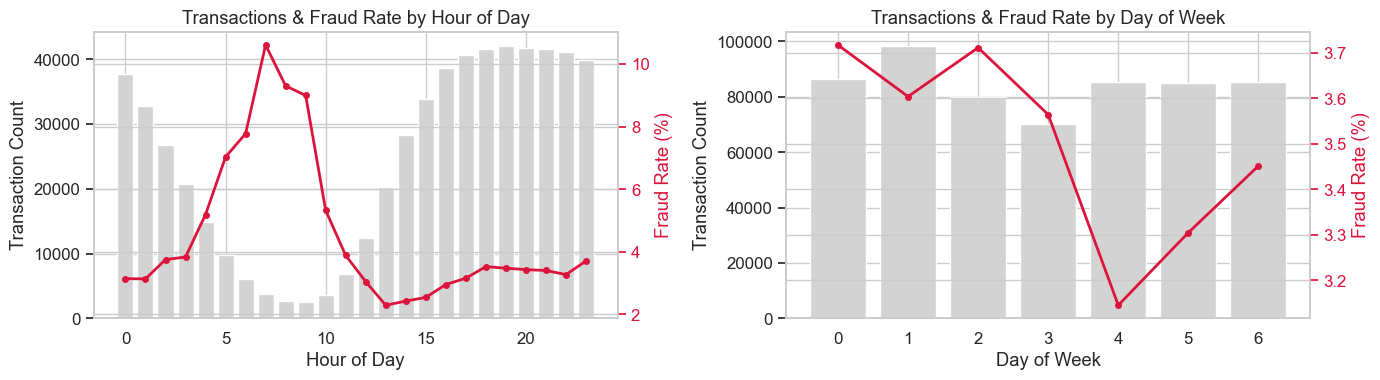

In [9]:
dt = trn["TransactionDT"]
print("TransactionDT stats (seconds offset from reference):")
print(dt.describe().to_string())
span_days   = (dt.max() - dt.min()) / 86400
span_months = span_days / 30
print(f"Span: {span_days:.1f} days  ({span_months:.1f} months)")

trn_tmp = trn[["TransactionDT", "isFraud"]].copy()
trn_tmp["hour_of_day"] = (trn_tmp["TransactionDT"] // 3600) % 24
trn_tmp["day_of_week"] = (trn_tmp["TransactionDT"] // 86400) % 7

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(
    axes,
    ["hour_of_day", "day_of_week"],
    ["Hour of Day", "Day of Week"],
):
    fraud_rate = trn_tmp.groupby(col)["isFraud"].mean() * 100
    counts     = trn_tmp.groupby(col)["isFraud"].count()
    ax2 = ax.twinx()
    ax.bar(fraud_rate.index, counts.values, color="lightgray")
    ax2.plot(fraud_rate.index, fraud_rate.values,
             color="crimson", lw=2, marker="o", ms=4)
    ax.set_title(f"Transactions & Fraud Rate by {title}")
    ax.set_xlabel(title)
    ax.set_ylabel("Transaction Count")
    ax2.set_ylabel("Fraud Rate (%)", color="crimson")
    ax2.tick_params(axis="y", colors="crimson")
plt.tight_layout()
plt.show()

## 9. Categorical Feature Analysis

In [10]:
all_cats = trn_cats + idn_cats
print("Categorical feature cardinality & missing %:")
rows = []
for col in all_cats:
    src  = trn if col in trn.columns else idn
    card = src[col].nunique()
    miss = src[col].isnull().mean() * 100
    vc   = src[col].value_counts()
    tv   = vc.index[0]   if len(vc) > 0 else None
    tf   = vc.iloc[0] / len(src) * 100 if len(vc) > 0 else None
    rows.append({
        "column": col, "cardinality": card,
        "missing_pct": round(miss, 1),
        "top_value": tv,
        "top_freq_pct": round(tf, 1) if tf is not None else None,
    })
cat_df = pd.DataFrame(rows).set_index("column")
print(cat_df.to_string())

Categorical feature cardinality & missing %:
               cardinality  missing_pct             top_value  top_freq_pct
column                                                                     
ProductCD                5       0.0000                     W       74.5000
card4                    4       0.3000                  visa       65.2000
card6                    4       0.3000                 debit       74.5000
P_emaildomain           59      16.0000             gmail.com       38.7000
R_emaildomain           60      76.8000             gmail.com        9.7000
M1                       2      45.9000                     T       54.1000
M2                       2      45.9000                     T       48.3000
M3                       2      45.9000                     T       42.6000
M4                       3      47.7000                    M0       33.3000
M5                       2      59.3000                     F       22.4000
M6                       2      28.7000    

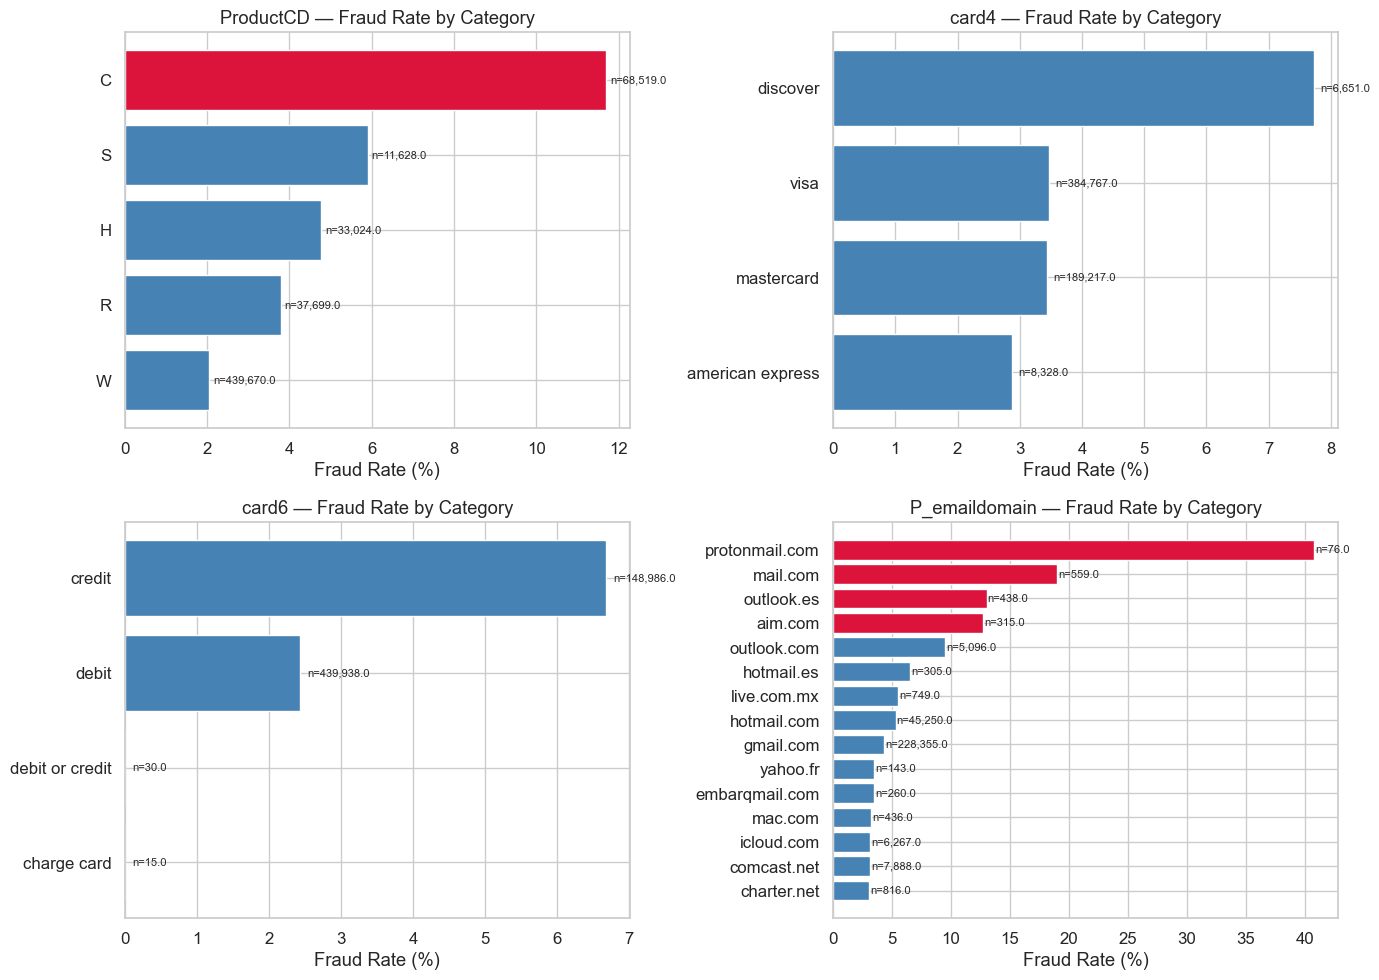

In [11]:
key_cats = ["ProductCD", "card4", "card6", "P_emaildomain"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, col in zip(axes, key_cats):
    grp = (
        trn.groupby(col)["isFraud"]
           .agg(["mean", "count"])
           .rename(columns={"mean": "fraud_rate", "count": "n"})
           .sort_values("fraud_rate", ascending=True)
           .tail(15)
    )
    grp["fraud_rate"] *= 100
    colors = ["crimson" if r > 10 else "steelblue" for r in grp["fraud_rate"]]
    bars = ax.barh(grp.index.astype(str), grp["fraud_rate"], color=colors)
    ax.set_xlabel("Fraud Rate (%)")
    ax.set_title(f"{col} — Fraud Rate by Category")
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f"n={row['n']:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 10. Identity Coverage & Device Analysis

Transactions with identity data: 144,233 / 590,540 (24.4%)
Fraud rate by identity coverage:
has_identity
False   2.0939
True    7.8470
Name: isFraud, dtype: float64

DeviceType distribution:
DeviceType
desktop    85165
mobile     55645
NaN         3423
Name: count, dtype: int64


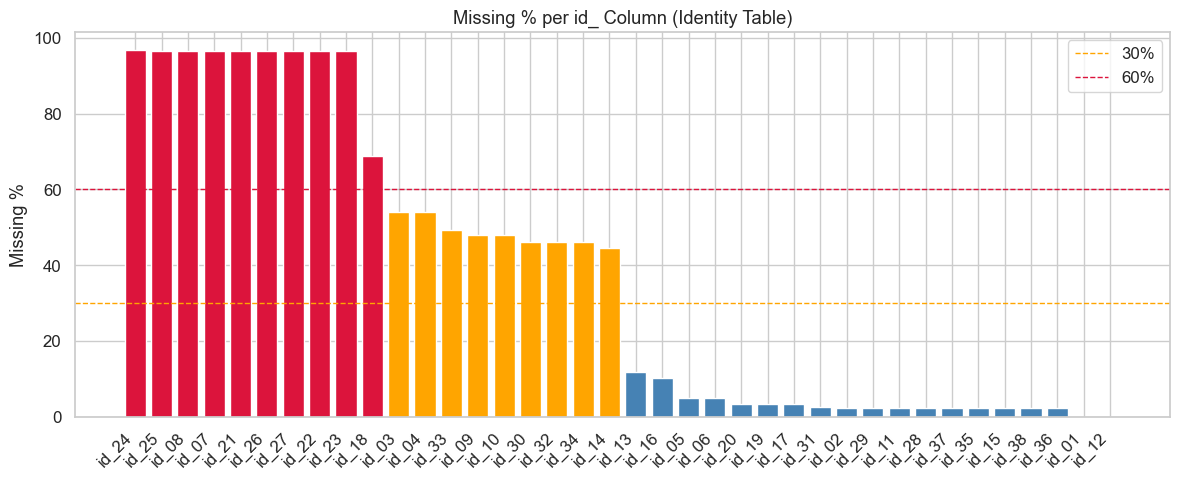

In [12]:
coverage = trn["TransactionID"].isin(idn["TransactionID"])
print(f"Transactions with identity data: "
      f"{coverage.sum():,} / {len(trn):,} ({coverage.mean()*100:.1f}%)")
print("Fraud rate by identity coverage:")
print(trn.groupby(coverage.rename("has_identity"))["isFraud"].mean() * 100)

print()
print("DeviceType distribution:")
print(idn["DeviceType"].value_counts(dropna=False))

id_cols = [c for c in idn.columns if c.startswith("id_")]
id_miss = (idn[id_cols].isnull().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(id_miss)), id_miss.values,
       color=["crimson" if p > 60 else ("orange" if p > 30 else "steelblue")
              for p in id_miss.values])
ax.set_xticks(range(len(id_miss)))
ax.set_xticklabels(id_miss.index, rotation=45, ha="right")
ax.set_ylabel("Missing %")
ax.set_title("Missing % per id_ Column (Identity Table)")
ax.axhline(30, color="orange", ls="--", lw=1, label="30%")
ax.axhline(60, color="crimson", ls="--", lw=1, label="60%")
ax.legend()
plt.tight_layout()
plt.show()

## 11. V-Feature Group — Near-Zero Variance & Missingness

V-features total                   : 339
Near-zero variance (std < 0.01)    : 2
Missing > 90%                      : 0


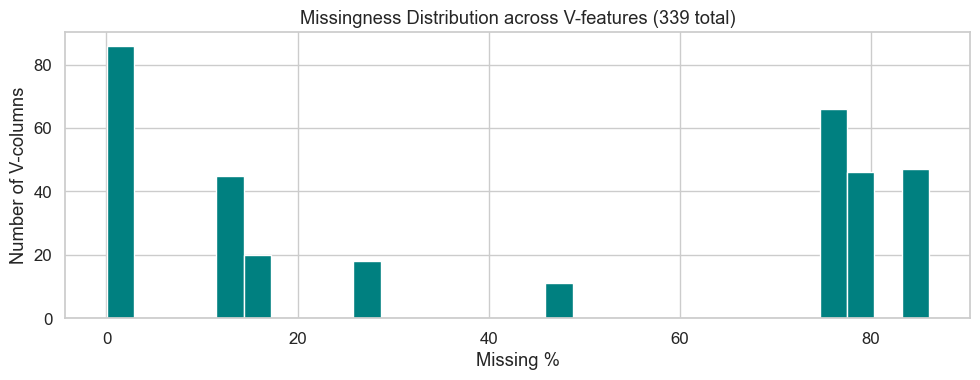

In [13]:
v_cols = [c for c in trn.columns if c.startswith("V")]
v_stats = trn[v_cols].describe().T
v_stats["missing_pct"] = trn[v_cols].isnull().mean() * 100
v_stats["unique"]      = trn[v_cols].nunique()

nzv         = v_stats[v_stats["std"] < 0.01]
high_miss_v = v_stats[v_stats["missing_pct"] > 90]

print(f"V-features total                   : {len(v_cols)}")
print(f"Near-zero variance (std < 0.01)    : {len(nzv)}")
print(f"Missing > 90%                      : {len(high_miss_v)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(v_stats["missing_pct"], bins=30, color="teal", edgecolor="white")
ax.set_xlabel("Missing %")
ax.set_ylabel("Number of V-columns")
ax.set_title("Missingness Distribution across V-features (339 total)")
plt.tight_layout()
plt.show()

## 12. M-Feature Group — Match Flags

In [14]:
m_cols = [c for c in trn.columns if c.startswith("M")]
print("M-feature unique values & missingness:")
for c in m_cols:
    vc   = trn[c].value_counts(dropna=False)
    miss = trn[c].isnull().mean() * 100
    print(f"  {c}: {dict(list(vc.items())[:5])}  |  missing={miss:.1f}%")

M-feature unique values & missingness:
  M1: {'T': 319415, nan: 271100, 'F': 25}  |  missing=45.9%
  M2: {'T': 285468, nan: 271100, 'F': 33972}  |  missing=45.9%
  M3: {nan: 271100, 'T': 251731, 'F': 67709}  |  missing=45.9%
  M4: {nan: 281444, 'M0': 196405, 'M2': 59865, 'M1': 52826}  |  missing=47.7%
  M5: {nan: 350482, 'F': 132491, 'T': 107567}  |  missing=59.3%
  M6: {'F': 227856, 'T': 193324, nan: 169360}  |  missing=28.7%
  M7: {nan: 346265, 'F': 211374, 'T': 32901}  |  missing=58.6%
  M8: {nan: 346252, 'F': 155251, 'T': 89037}  |  missing=58.6%
  M9: {nan: 346252, 'T': 205656, 'F': 38632}  |  missing=58.6%


## 13. Correlation with Target

Top-20 features most correlated with isFraud:
V257   0.3831
V246   0.3669
V244   0.3641
V242   0.3606
V201   0.3280
V200   0.3188
V189   0.3082
V188   0.3036
V258   0.2972
V45    0.2818
V158   0.2781
V156   0.2760
V149   0.2733
V228   0.2689
V44    0.2604
V86    0.2518
V87    0.2517
V170   0.2498
V147   0.2429
V52    0.2395


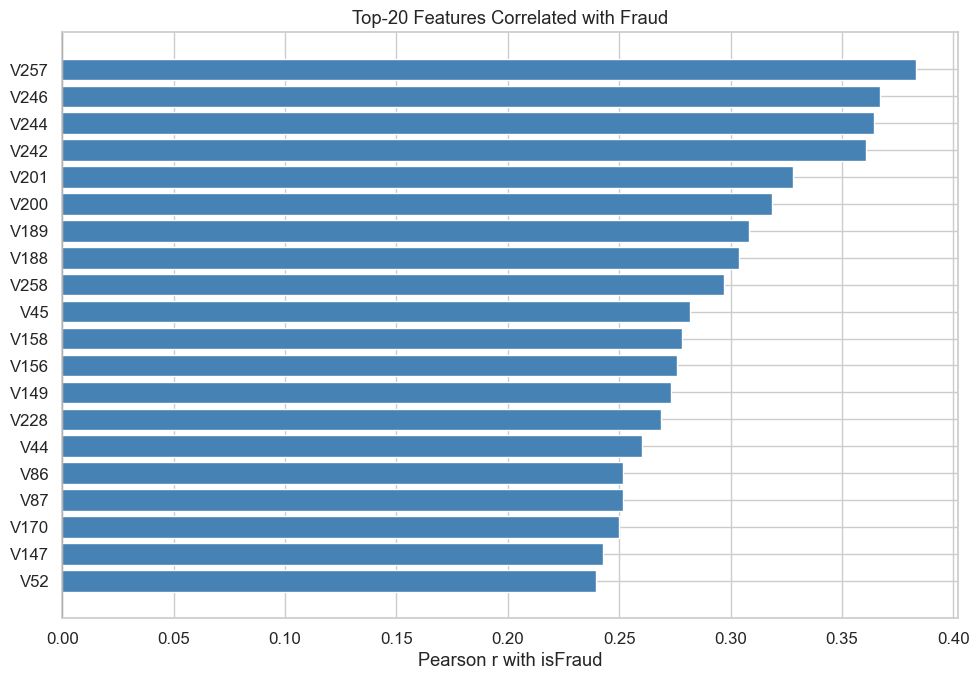

In [15]:
num_subset = [c for c in trn_nums if c not in ("isFraud", "TransactionDT")]
corr_target = (
    trn[num_subset + ["isFraud"]]
    .corr()["isFraud"]
    .drop("isFraud")
    .dropna()
    .sort_values(key=abs, ascending=False)
)

print("Top-20 features most correlated with isFraud:")
print(corr_target.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
top20  = corr_target.head(20)
colors = ["crimson" if v < 0 else "steelblue" for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r with isFraud")
ax.set_title("Top-20 Features Correlated with Fraud")
plt.tight_layout()
plt.show()

## 14. Card Feature Cardinality

In [16]:
card_cols = [c for c in trn.columns if c.startswith("card")]
print("Card features:")
for c in card_cols:
    dtype = trn[c].dtype
    nuniq = trn[c].nunique()
    miss  = trn[c].isnull().mean() * 100
    print(f"  {c:8s}  dtype={str(dtype):8s}  unique={nuniq:6,}  missing={miss:.1f}%")

Card features:
  card1     dtype=int64     unique=13,553  missing=0.0%
  card2     dtype=float64   unique=   500  missing=1.5%
  card3     dtype=float64   unique=   114  missing=0.3%
  card4     dtype=object    unique=     4  missing=0.3%
  card5     dtype=float64   unique=   119  missing=0.7%
  card6     dtype=object    unique=     4  missing=0.3%


## 15. Preprocessing Conclusions

In [17]:
all_trn_miss   = trn.isnull().mean() * 100
to_drop        = all_trn_miss[all_trn_miss > 95].index.tolist()
high_skew_cols = num_stats[num_stats["skewness"].abs() > 5].index.tolist()
high_card_cats = [c for c in trn_cats if trn[c].nunique() > 50]
low_card_cats  = [c for c in trn_cats if trn[c].nunique() <= 50]
remaining_miss = int(
    (all_trn_miss[(all_trn_miss > 0) & (all_trn_miss <= 95)]).shape[0]
)

sep = "=" * 66
lines = [
    sep, "PREPROCESSING DECISIONS SUMMARY", sep, "",
    "1. CLASS IMBALANCE",
    "   Fraud rate ~3.5%,  imbalance ratio ~28:1.",
    '   -> class_weight="balanced" (LightGBM/XGBoost) or SMOTE.',
    "   -> Evaluation metric: AUROC + F1  (NOT accuracy).",
    "",
    "2. MISSING VALUES (transaction table)",
    f"   Columns with >95% missing   : {len(to_drop)}",
    "   Action: DROP these columns — no signal, no imputation.",
    "",
    f"   Remaining columns with NaN  : {remaining_miss}",
    "   Numerical   -> median imputation + binary <col>_isnan flag.",
    '   Categorical -> fill with literal "unknown" (new category).',
    "   M-flags     -> fill unknown; ordinal encode T/F/unknown=1/0/2.",
    "",
    "3. IDENTITY TABLE COVERAGE (~24% of rows)",
    "   Add boolean feature has_identity (fraud rate differs by group).",
    "   Rows without identity: all id_ cols become NaN -> imputed above.",
    "",
    "4. SKEWED NUMERICAL FEATURES",
    f"   Columns with |skewness| > 5  : {len(high_skew_cols)}",
    "   -> log1p transform (mandatory for TransactionAmt).",
    "   -> For tree models: log1p still improves split quality.",
    "",
    "5. SCALING",
    "   Trees (LightGBM / XGBoost)  : NO scaling required.",
    "   Linear / distance-based     : RobustScaler (IQR-based,",
    "                                  robust to remaining outliers).",
    "",
    "6. CATEGORICAL ENCODING",
    f"   High-cardinality (>50 unique): {high_card_cats}",
    "   -> Frequency encoding or target encoding with CV leakage guard.",
    "",
    f"   Low-cardinality (<=50 unique): {low_card_cats}",
    "   -> Label encoding (trees) or one-hot (linear models).",
    "",
    "7. FEATURE ENGINEERING",
    "   a) hour_of_day, day_of_week from TransactionDT.",
    "      (sin/cos cyclic encoding for linear models).",
    "   b) log1p(TransactionAmt).",
    "   c) Card aggregates: tx count & mean amount per card1.",
    "   d) has_identity binary flag.",
    "",
    "8. V-FEATURE DIMENSIONALITY (339 columns)",
    "   -> Drop near-zero-variance V-cols and those missing >95%.",
    "   -> Optional PCA on V-block after imputation & scaling.",
    "",
    "9. TRAIN/VALIDATION SPLIT STRATEGY",
    "   TransactionDT is time-ordered -> TIME-BASED split only.",
    "   Last ~20% of time window = held-out validation set.",
    "   Random shuffle split causes temporal data leakage.",
    sep,
]
print("\n".join(lines))

PREPROCESSING DECISIONS SUMMARY

1. CLASS IMBALANCE
   Fraud rate ~3.5%,  imbalance ratio ~28:1.
   -> class_weight="balanced" (LightGBM/XGBoost) or SMOTE.
   -> Evaluation metric: AUROC + F1  (NOT accuracy).

2. MISSING VALUES (transaction table)
   Columns with >95% missing   : 0
   Action: DROP these columns — no signal, no imputation.

   Remaining columns with NaN  : 374
   Numerical   -> median imputation + binary <col>_isnan flag.
   Categorical -> fill with literal "unknown" (new category).
   M-flags     -> fill unknown; ordinal encode T/F/unknown=1/0/2.

3. IDENTITY TABLE COVERAGE (~24% of rows)
   Add boolean feature has_identity (fraud rate differs by group).
   Rows without identity: all id_ cols become NaN -> imputed above.

4. SKEWED NUMERICAL FEATURES
   Columns with |skewness| > 5  : 278
   -> log1p transform (mandatory for TransactionAmt).
   -> For tree models: log1p still improves split quality.

5. SCALING
   Trees (LightGBM / XGBoost)  : NO scaling required.
   Li